# Switch-Centered Local PH: Topological Arcs at Regime Transitions

This notebook implements the analyses reported in the manuscript text for switch-centered topological arcs around HMM regime transitions. It focuses on the primary real-vs-pseudo comparison, switch-level growth-slope summaries and moderation tests, and session-level moderation by regime geometry.



In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SRC_DIR = Path('../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["axes.grid"] = False
plt.rcParams["svg.fonttype"] = "none"

ARTIFACTS_DIR = Path("../artifacts")
CHMM_DIR = ARTIFACTS_DIR / "03_chmm_outputs" / "chmm_8_full_dataset"
PHASE_DIR = ARTIFACTS_DIR / "07_transitions"

FIG_DIR = PHASE_DIR / "notebook_figures"
TAB_DIR = PHASE_DIR / "notebook_tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("CHMM_DIR exists:", CHMM_DIR.exists())
print("PHASE_DIR exists:", PHASE_DIR.exists())

TOPO_FEATURES = [
    "total_persistence_h1",
    "betti_h1_auc",
    "persistence_entropy_h1",
]

PRIMARY_WINDOW_LABELS = [
    "far_before",
    "near_before",
    "transition",
    "near_after",
    "far_after",
]


CHMM_DIR exists: True
PHASE_DIR exists: True


## 1. Load Outputs
If the phase-transition outputs are missing, run `make phase-transitions` first.

In [2]:
rolling_path = PHASE_DIR / "rolling_ph_timeseries.csv"
aligned_path = PHASE_DIR / "switch_aligned_rolling_ph.csv"
combined_aligned_path = PHASE_DIR / "combined_aligned_rolling_ph.csv"
switch_path = PHASE_DIR / "switch_local_segment_ph.csv"
delta_path = PHASE_DIR / "switch_reorganization_delta.csv"
jump_assoc_path = PHASE_DIR / "switch_jump_association.csv"
transition_summary_path = PHASE_DIR / "switch_transition_type_reorganization.csv"
matched_anchors_path = PHASE_DIR / "matched_real_pseudo_anchors.csv"

required = [combined_aligned_path, switch_path]
missing = [p for p in required if not p.exists()]
if missing:
    print("Missing core phase-transition outputs:")
    for p in missing:
        print(" -", p)
    print("Run `make phase-transitions` first.")
    df_aligned_raw = pd.DataFrame()
    df_switch_raw = pd.DataFrame()
    df_rolling_raw = pd.DataFrame()
    df_matched_anchors = pd.DataFrame()
else:
    df_aligned_raw = pd.read_csv(combined_aligned_path)
    df_switch_raw = pd.read_csv(switch_path)
    df_rolling_raw = pd.read_csv(rolling_path) if rolling_path.exists() else pd.DataFrame()
    df_matched_anchors = pd.read_csv(matched_anchors_path) if matched_anchors_path.exists() else pd.DataFrame()
    print("Loaded aligned rows (real+pseudo):", df_aligned_raw.shape)
    print("Loaded switch rows:", df_switch_raw.shape)
    print("Loaded rolling rows:", df_rolling_raw.shape)
    print("Loaded matched anchor rows:", df_matched_anchors.shape)

display(df_aligned_raw.head(3) if not df_aligned_raw.empty else pd.DataFrame())
from affectdynamics.eval.transitions import (
    build_analysis_table,
    make_publication_figures,
    run_growth_analysis,
    run_posterior_control_analysis,
    run_primary_anchor_timecourse,
    run_primary_inferential_analysis,
    run_session_geometry_analysis,
    run_session_level_robustness,
    run_transition_identity_analysis,
)


Loaded aligned rows (real+pseudo): (1214206, 26)
Loaded switch rows: (51078, 15)
Loaded rolling rows: (41723, 16)
Loaded matched anchor rows: (50107, 4)


,session_id,dyad_id,time_idx,time_sec,window_sec,step_sec,metric,m,tau_sec,posterior_entropy,...,rel_time_idx,rel_time_sec,switch_index,switch_time_idx,from_state,to_state,transition_type,posterior_jump_l2,phase,anchor_kind
0,001_A,1,15,15.0,30.0,5.0,euclidean,10,1.0,0.076815,...,9,9.0,0,6,0,2,0->2,1.280034,after,real
1,001_A,1,20,20.0,30.0,5.0,euclidean,10,1.0,0.577487,...,14,14.0,0,6,0,2,0->2,1.280034,after,real
2,001_A,1,25,25.0,30.0,5.0,euclidean,10,1.0,0.778908,...,19,19.0,0,6,0,2,0->2,1.280034,after,real


## 2. Build Unified Analysis Table
This section creates one analysis-ready table used throughout the notebook.

In [3]:
if df_aligned_raw.empty or df_switch_raw.empty:
    print("No aligned/switch data available yet.")
    df_main = pd.DataFrame()
    df_switch_labels = pd.DataFrame()
else:
    df_main, df_switch_labels = build_analysis_table(
        df_aligned_raw,
        df_switch_raw,
        CHMM_DIR,
        TOPO_FEATURES,
    )
    print("Built analysis table:", df_main.shape)
    print("Built switch-label table:", df_switch_labels.shape)
    display(df_switch_labels.head(5))
    display(df_main.head(5))



Built analysis table: (1214206, 61)
Built switch-label table: (51078, 32)


,session_id,switch_index,from_state,to_state,transition_type,posterior_jump_l2,transition_identity,jump_magnitude_bin,from_run_len,to_run_len,...,z_from_run_len,z_to_run_len,z_log_from_run_len,z_log_to_run_len,z_client_valence_from,z_client_valence_to,z_client_valence_delta,z_therapist_valence_from,z_therapist_valence_to,z_therapist_valence_delta
0,001_A,0,0,2,0->2,1.280034,0->2,large,6,2,...,0.256460,-0.253177,0.946024,-0.202354,0.493925,-1.621073,-1.805939,-0.606000,0.906425,1.342469
1,001_A,1,2,4,2->4,1.112095,2->4,medium,2,1,...,-0.285978,-0.371865,-0.201936,-0.750904,-1.623044,0.644180,1.935433,0.907021,0.844494,-0.055126
2,001_A,2,4,6,4->6,0.041470,4->6,small,1,1,...,-0.421587,-0.371865,-0.751280,-0.750904,0.643394,0.617224,-0.022061,0.845060,0.901922,0.050841
3,001_A,3,6,4,6->4,0.178276,6->4,small,1,1,...,-0.421587,-0.371865,-0.751280,-0.750904,0.616424,0.644180,0.023978,0.902516,0.844494,-0.051129
4,001_A,4,4,6,4->6,0.364406,4->6,small,1,1,...,-0.421587,-0.371865,-0.751280,-0.750904,0.643394,0.617224,-0.022061,0.845060,0.901922,0.050841


,session_id,dyad_id,time_idx,time_sec,window_sec,step_sec,metric,m,tau_sec,posterior_entropy,...,to_state,phase_window_5,abs_rel_time_sec,norm_session_time,total_persistence_h1_baseline,total_persistence_h1_baseline_centered,betti_h1_auc_baseline,betti_h1_auc_baseline_centered,persistence_entropy_h1_baseline,persistence_entropy_h1_baseline_centered
0,001_A,1,15,15.0,30.0,5.0,euclidean,10,1.0,0.076815,...,2,near_after,9.0,0.008427,NaN,NaN,NaN,NaN,NaN,NaN
1,001_A,1,20,20.0,30.0,5.0,euclidean,10,1.0,0.577487,...,2,near_after,14.0,0.011236,NaN,NaN,NaN,NaN,NaN,NaN
2,001_A,1,25,25.0,30.0,5.0,euclidean,10,1.0,0.778908,...,2,far_after,19.0,0.014045,NaN,NaN,NaN,NaN,NaN,NaN
3,001_A,1,30,30.0,30.0,5.0,euclidean,10,1.0,0.141898,...,2,far_after,24.0,0.016854,NaN,NaN,NaN,NaN,NaN,NaN
4,001_A,1,35,35.0,30.0,5.0,euclidean,10,1.0,0.581222,...,2,far_after,29.0,0.019663,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Primary Test: Descriptive Time Courses

We first visualize the average switch-centered topological trajectory for real versus matched pseudo anchors across the full $\pm 30$ s window.



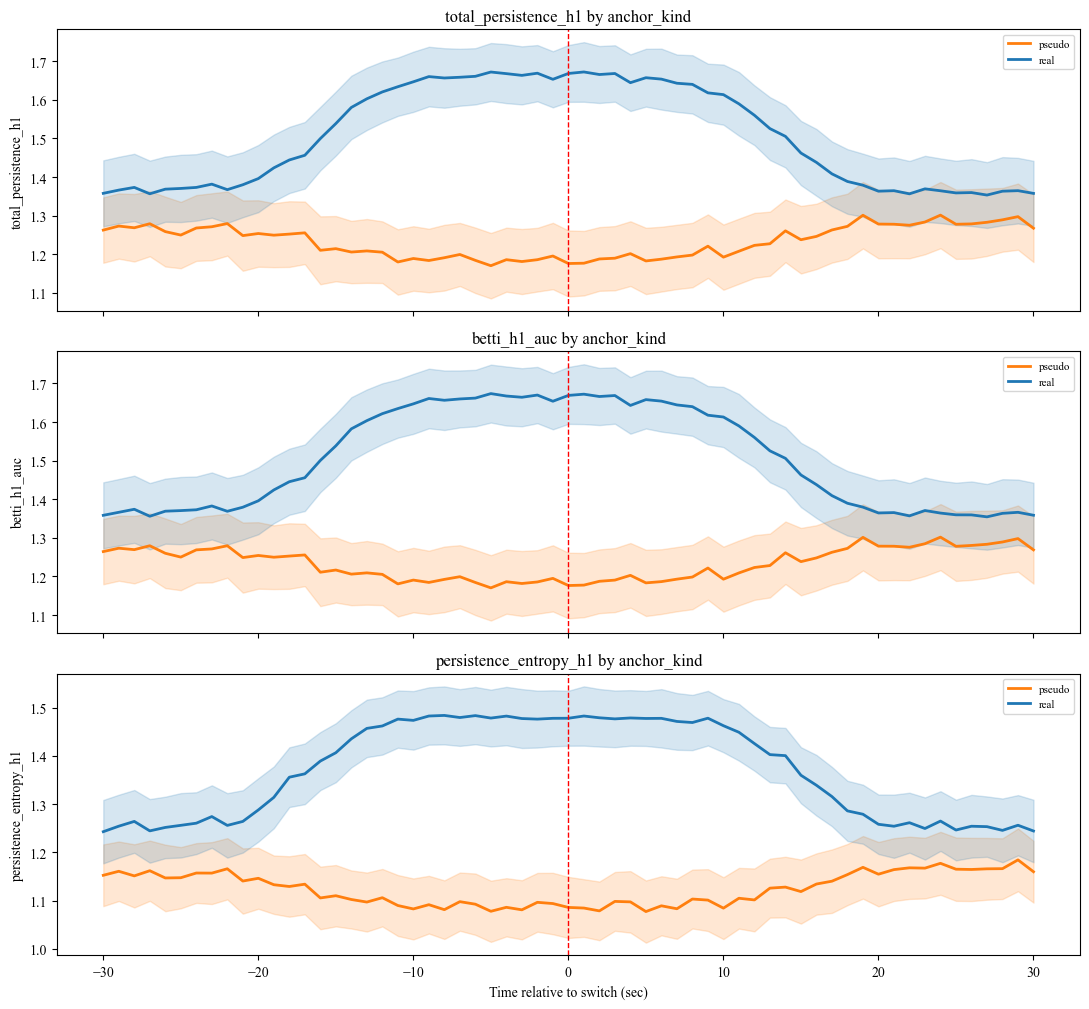

,anchor_kind,rel_time_sec,mean,sd,n,sem,lower,upper,feature
0,pseudo,-30.0,1.262724,0.446248,107,0.043140,1.178168,1.347279,total_persistence_h1
1,pseudo,-29.0,1.273123,0.445451,107,0.043063,1.188719,1.357527,total_persistence_h1
2,pseudo,-28.0,1.268702,0.460506,107,0.044519,1.181445,1.355958,total_persistence_h1
3,pseudo,-27.0,1.279137,0.444049,107,0.042928,1.194998,1.363275,total_persistence_h1
4,pseudo,-26.0,1.258767,0.476387,107,0.046054,1.168501,1.349033,total_persistence_h1
5,pseudo,-25.0,1.249844,0.452796,107,0.043773,1.164048,1.335640,total_persistence_h1
6,pseudo,-24.0,1.268121,0.448990,107,0.043406,1.183046,1.353196,total_persistence_h1
7,pseudo,-23.0,1.271339,0.456809,107,0.044161,1.184783,1.357896,total_persistence_h1
8,pseudo,-22.0,1.279572,0.437874,107,0.042331,1.196603,1.362541,total_persistence_h1
9,pseudo,-21.0,1.248416,0.480087,107,0.046412,1.157449,1.339383,total_persistence_h1


In [4]:
df_primary_sum = run_primary_anchor_timecourse(df_main, TOPO_FEATURES, FIG_DIR, TAB_DIR)
display(df_primary_sum.head(10) if not df_primary_sum.empty else pd.DataFrame())



## 5. Primary Test: Mixed-Effects Spline Model

This section fits the manuscript's primary mixed-effects cubic spline model testing whether the shape of the topological trajectory differs between real and pseudo anchors over relative time.



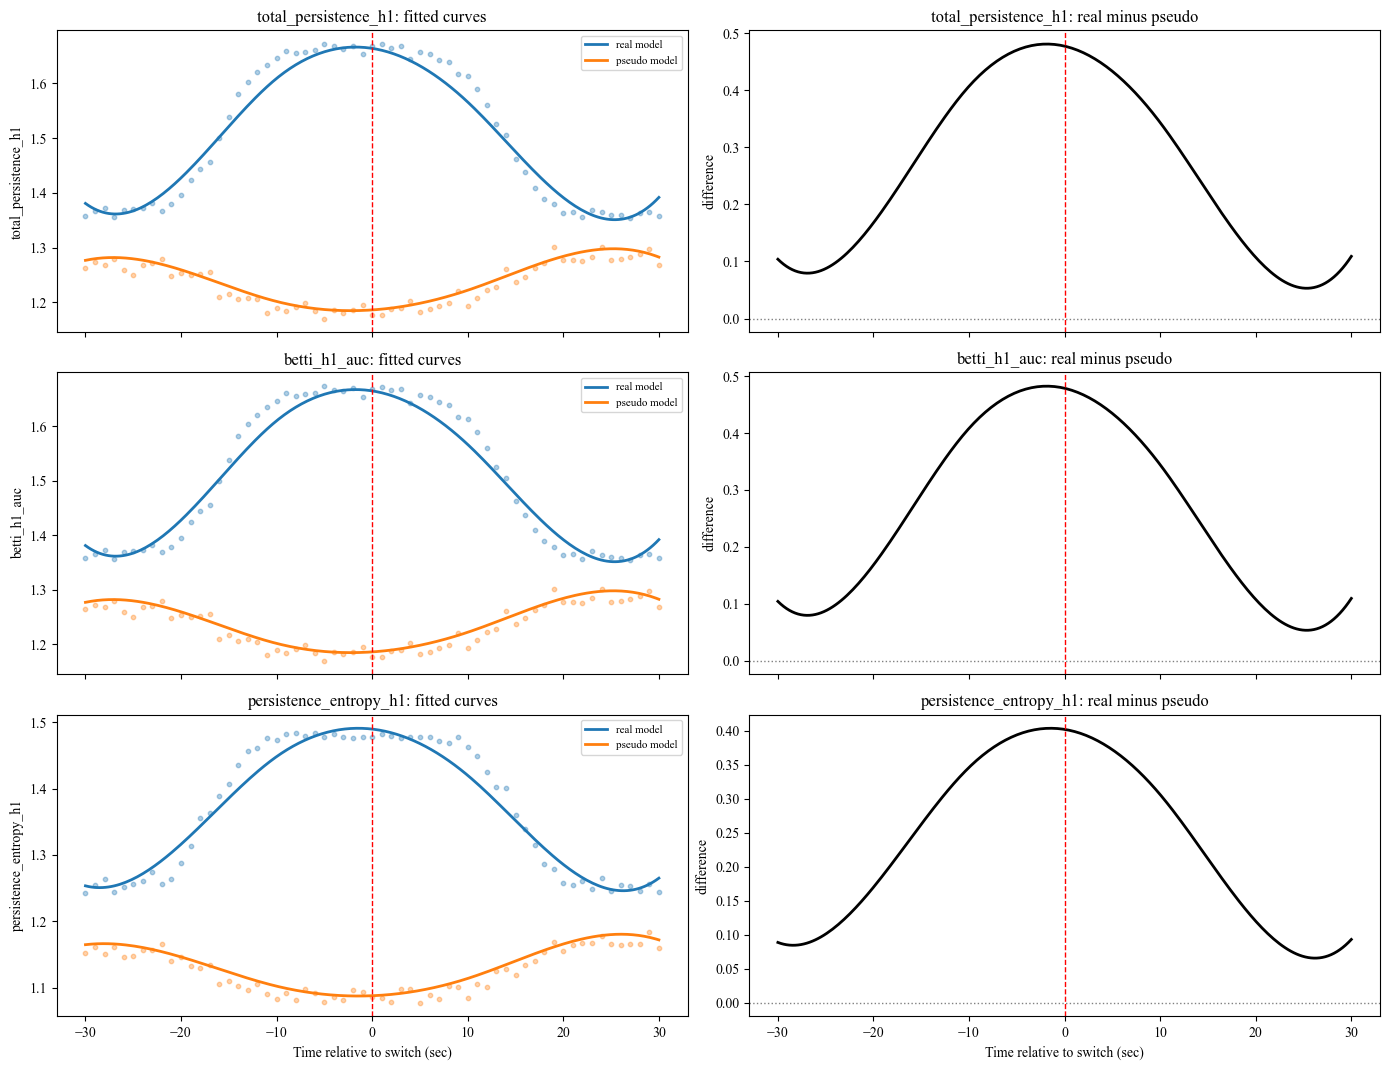

,feature,model_type,spline_df_used,n_obs,n_sessions,ll_full,ll_reduced,lr_stat,df_diff,p_value,aic_full,bic_full,aic_reduced,bic_reduced
0,total_persistence_h1,MixedLM_time_x_anchor_lr,5,1214206,108,-1.806543e+06,-1.809688e+06,6290.542731,5,0.0,3.613113e+06,3.613281e+06,3.619394e+06,3.619502e+06
1,betti_h1_auc,MixedLM_time_x_anchor_lr,5,1214206,108,-1.810692e+06,-1.813830e+06,6275.771144,5,0.0,3.621413e+06,3.621581e+06,3.627679e+06,3.627787e+06
2,persistence_entropy_h1,MixedLM_time_x_anchor_lr,5,1214206,108,-1.479653e+06,-1.483008e+06,6708.721447,5,0.0,2.959335e+06,2.959503e+06,2.966034e+06,2.966142e+06


In [5]:
df_primary_model, df_primary_diff = run_primary_inferential_analysis(
    df_main,
    TOPO_FEATURES,
    FIG_DIR,
    TAB_DIR,
)

## 6. Growth Slopes, Arc Moderation, Continuous Moderators, and Fluctuation Analyses

To complement the continuous time-course model with interpretable effect-size summaries, this section estimates switch-level linear slopes in the pre-switch ($-20$ to $-5$ s) and post-switch ($+5$ to $+20$ s) windows. It retains the descriptive discrete moderator summaries, but shifts the main inferential supplement toward continuous transition indices: departing and arriving dwell, posterior jump magnitude, and therapist/client valence deltas. It also adds continuous spline likelihood-ratio tests for whether topology time courses vary over relative time as a function of those continuous indices, plus switch-level fluctuation summaries that quantify volatility asymmetry before versus after switches and local roughness near the anchor.

In [6]:
growth_cache_paths = {
    "df_growth": TAB_DIR / "switch_growth_slopes.csv",
    "df_growth_summary": TAB_DIR / "switch_growth_slope_summary.csv",
    "df_growth_models": TAB_DIR / "switch_growth_anchor_kind_mixed_model.csv",
    "df_growth_jump": TAB_DIR / "switch_growth_jump_association.csv",
    "df_growth_moderation_input": TAB_DIR / "switch_growth_moderation_input.csv",
    "df_growth_moderation_models": TAB_DIR / "switch_growth_moderation_mixed_models.csv",
    "df_growth_continuous_dwell_models": TAB_DIR / "switch_growth_continuous_dwell_mixed_models.csv",
    "df_growth_continuous_transition_models": TAB_DIR / "switch_growth_continuous_transition_mixed_models.csv",
    "df_jump_moderator_summary": TAB_DIR / "moderator_jump_magnitude_timecourses_real_only_summary.csv",
    "df_jump_moderator_models": TAB_DIR / "moderator_jump_magnitude_timecourses_real_only_model_summary.csv",
    "df_stability_moderator_summary": TAB_DIR / "moderator_regime_stability_timecourses_real_only_summary.csv",
    "df_stability_moderator_models": TAB_DIR / "moderator_regime_stability_timecourses_real_only_model_summary.csv",
    "df_client_valence_moderator_summary": TAB_DIR / "moderator_client_valence_direction_timecourses_real_only_summary.csv",
    "df_client_valence_moderator_models": TAB_DIR / "moderator_client_valence_direction_timecourses_real_only_model_summary.csv",
    "df_therapist_valence_moderator_summary": TAB_DIR / "moderator_therapist_valence_direction_timecourses_real_only_summary.csv",
    "df_therapist_valence_moderator_models": TAB_DIR / "moderator_therapist_valence_direction_timecourses_real_only_model_summary.csv",
    "df_moderator_omnibus_models": TAB_DIR / "moderator_timecourse_omnibus_model_summary.csv",
    "df_continuous_moderator_models": TAB_DIR / "continuous_moderator_timecourse_omnibus_model_summary.csv",
    "df_continuous_moderator_predicted_curves": TAB_DIR / "continuous_moderator_timecourse_predicted_curves.csv",
    "df_continuous_moderator_correlations": TAB_DIR / "continuous_moderator_correlation_matrix_long.csv",
    "df_fluctuation_input": TAB_DIR / "switch_fluctuation_analysis_table.csv",
    "df_fluctuation_models": TAB_DIR / "switch_fluctuation_mixed_models.csv",
}

if all(path.exists() for path in growth_cache_paths.values()):
    print("Loading cached growth outputs from notebook_tables.")
    df_growth_base = pd.DataFrame()
    df_growth = pd.read_csv(growth_cache_paths["df_growth"])
    df_growth_summary = pd.read_csv(growth_cache_paths["df_growth_summary"])
    df_growth_models = pd.read_csv(growth_cache_paths["df_growth_models"])
    df_growth_jump = pd.read_csv(growth_cache_paths["df_growth_jump"])
    df_growth_moderation_input = pd.read_csv(growth_cache_paths["df_growth_moderation_input"])
    df_growth_moderation_models = pd.read_csv(growth_cache_paths["df_growth_moderation_models"])
    df_growth_continuous_dwell_models = pd.read_csv(growth_cache_paths["df_growth_continuous_dwell_models"])
    df_growth_continuous_transition_models = pd.read_csv(growth_cache_paths["df_growth_continuous_transition_models"])
    df_jump_moderator_summary = pd.read_csv(growth_cache_paths["df_jump_moderator_summary"])
    df_jump_moderator_models = pd.read_csv(growth_cache_paths["df_jump_moderator_models"])
    df_stability_moderator_summary = pd.read_csv(growth_cache_paths["df_stability_moderator_summary"])
    df_stability_moderator_models = pd.read_csv(growth_cache_paths["df_stability_moderator_models"])
    df_client_valence_moderator_summary = pd.read_csv(growth_cache_paths["df_client_valence_moderator_summary"])
    df_client_valence_moderator_models = pd.read_csv(growth_cache_paths["df_client_valence_moderator_models"])
    df_therapist_valence_moderator_summary = pd.read_csv(growth_cache_paths["df_therapist_valence_moderator_summary"])
    df_therapist_valence_moderator_models = pd.read_csv(growth_cache_paths["df_therapist_valence_moderator_models"])
    df_moderator_omnibus_models = pd.read_csv(growth_cache_paths["df_moderator_omnibus_models"])
    df_continuous_moderator_models = pd.read_csv(growth_cache_paths["df_continuous_moderator_models"])
    df_continuous_moderator_predicted_curves = pd.read_csv(growth_cache_paths["df_continuous_moderator_predicted_curves"])
    df_continuous_moderator_correlations = pd.read_csv(growth_cache_paths["df_continuous_moderator_correlations"])
    df_fluctuation_input = pd.read_csv(growth_cache_paths["df_fluctuation_input"])
    df_fluctuation_models = pd.read_csv(growth_cache_paths["df_fluctuation_models"])
else:
    print("Cached growth outputs missing; recomputing growth analyses.")
    growth_results = run_growth_analysis(df_main, TOPO_FEATURES, FIG_DIR, TAB_DIR)
    df_growth_base = growth_results['df_growth_base']
    df_growth = growth_results['df_growth']
    df_growth_summary = growth_results['df_growth_summary']
    df_growth_models = growth_results['df_growth_models']
    df_growth_jump = growth_results['df_growth_jump']
    df_growth_moderation_input = growth_results['df_growth_moderation_input']
    df_growth_moderation_models = growth_results['df_growth_moderation_models']
    df_growth_continuous_dwell_models = growth_results['df_growth_continuous_dwell_models']
    df_growth_continuous_transition_models = growth_results['df_growth_continuous_transition_models']
    df_jump_moderator_summary = growth_results['df_jump_moderator_summary']
    df_jump_moderator_models = growth_results['df_jump_moderator_models']
    df_stability_moderator_summary = growth_results['df_stability_moderator_summary']
    df_stability_moderator_models = growth_results['df_stability_moderator_models']
    df_client_valence_moderator_summary = growth_results['df_client_valence_moderator_summary']
    df_client_valence_moderator_models = growth_results['df_client_valence_moderator_models']
    df_therapist_valence_moderator_summary = growth_results['df_therapist_valence_moderator_summary']
    df_therapist_valence_moderator_models = growth_results['df_therapist_valence_moderator_models']
    df_moderator_omnibus_models = growth_results['df_moderator_omnibus_models']
    df_continuous_moderator_models = growth_results['df_continuous_moderator_models']
    df_continuous_moderator_predicted_curves = growth_results['df_continuous_moderator_predicted_curves']
    df_continuous_moderator_correlations = growth_results['df_continuous_moderator_correlations']
    df_fluctuation_input = growth_results['df_fluctuation_input']
    df_fluctuation_models = growth_results['df_fluctuation_models']

Loading cached growth outputs from notebook_tables.


The moderator plots now have matching omnibus likelihood-ratio tests asking whether the shape of the switch-centered trajectory varies by moderator over relative time within real switches. The tables below keep those time-course omnibus tests next to the existing slope-level moderator models.


In [ ]:
display(df_moderator_omnibus_models)
display(df_continuous_moderator_models)
display(df_continuous_moderator_correlations)
display(df_growth_continuous_transition_models)
display(df_fluctuation_models)
display(df_jump_moderator_models)
display(df_stability_moderator_models)
display(df_client_valence_moderator_models)
display(df_therapist_valence_moderator_models)

## 7. Session-Level Robustness, Posterior Controls, and Transition-Pair Heterogeneity

This section adds three manuscript-ready supplements: session-collapsed Wilcoxon robustness tests for the primary total-persistence effect, posterior-space control models that account for local entropy and posterior speed, and directed transition-pair heterogeneity summaries including 8x8 heat maps for arc magnitude and post-switch slope.


,metric,n_sessions,mean_difference,median_difference,wilcoxon_stat,p_value
0,session_mean_real_minus_pseudo_arc_magnitude,107,0.075791,0.056871,718.0,1.504214e-11
1,session_mean_real_minus_pseudo_post_switch_slope,107,-0.027247,-0.026418,22.0,5.072549e-19
2,session_mean_real_minus_pseudo_pre_switch_slope,107,0.024423,0.024537,44.0,9.377404e-19
3,session_peak_real_minus_pseudo_total_persistence,107,0.704268,0.676255,0.0,2.731261e-19


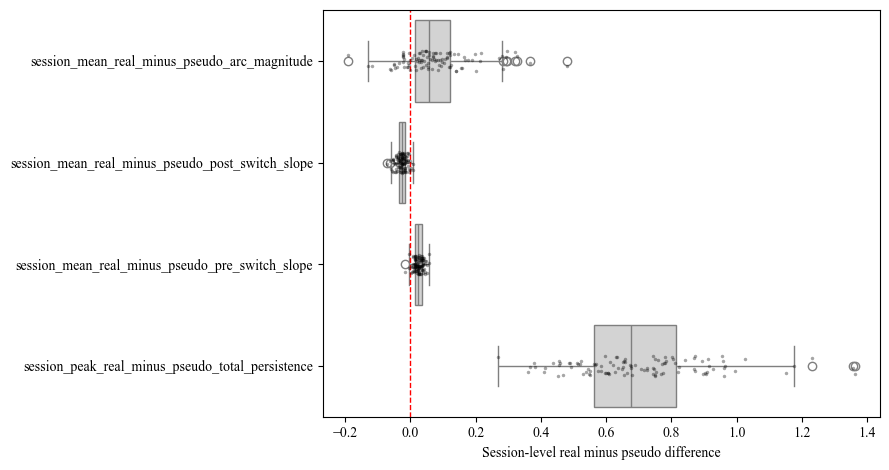

/Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,analysis,model_type,term,coef,se,p_value,n_obs,n_sessions
0,real_vs_pseudo_control_logit,GLM_binomial_clustered,const,0.039918,0.031021,1.981658e-01,100056,108
1,real_vs_pseudo_control_logit,GLM_binomial_clustered,z_total_persistence_h1,0.293250,0.018894,2.513876e-54,100056,108
2,real_vs_pseudo_control_logit,GLM_binomial_clustered,z_posterior_entropy,0.683501,0.029186,2.736494e-121,100056,108
3,real_vs_pseudo_control_logit,GLM_binomial_clustered,z_local_speed_l2,0.189320,0.017484,2.524232e-27,100056,108
4,post_switch_slope_control_mixedlm,MixedLM,Intercept,-0.013651,0.002019,1.352600e-11,9942,108
5,post_switch_slope_control_mixedlm,MixedLM,z_total_persistence_h1,-0.045320,0.000772,0.000000e+00,9942,108
6,post_switch_slope_control_mixedlm,MixedLM,z_posterior_entropy,0.005029,0.000829,1.320292e-09,9942,108
7,post_switch_slope_control_mixedlm,MixedLM,z_local_speed_l2,-0.002198,0.000920,1.683774e-02,9942,108
8,post_switch_slope_control_mixedlm,MixedLM,session_id Var,0.077710,0.012793,1.245276e-09,9942,108


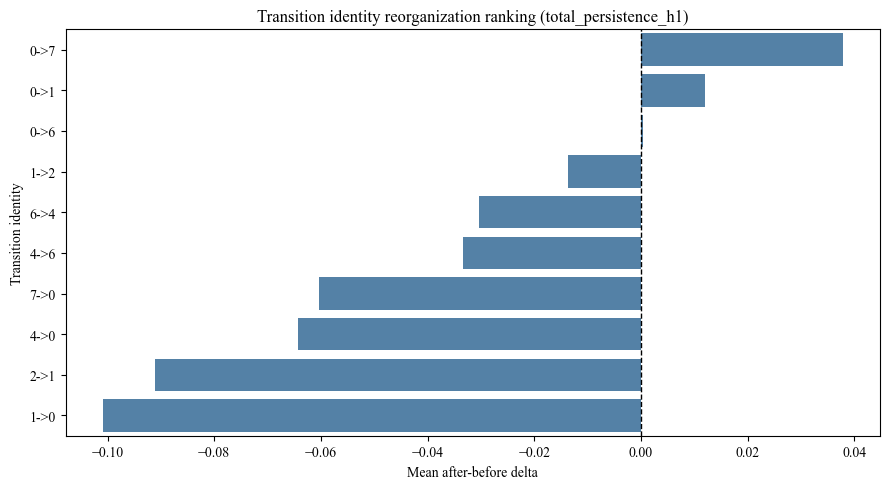

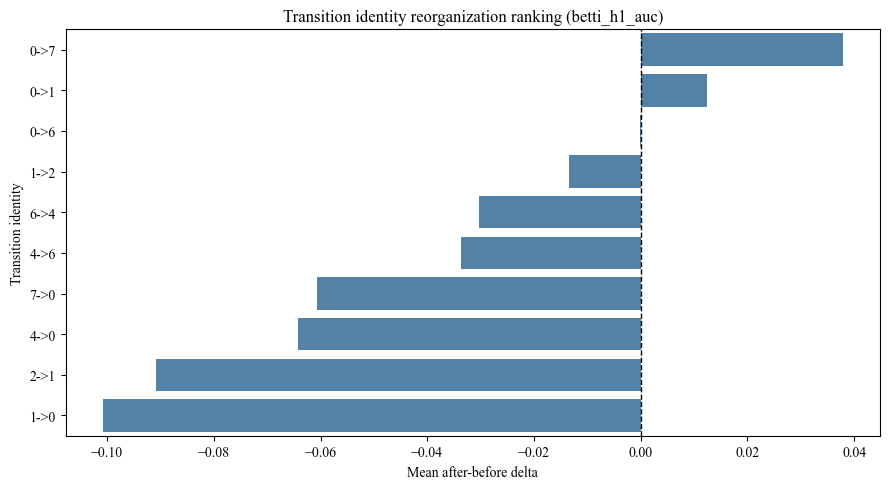

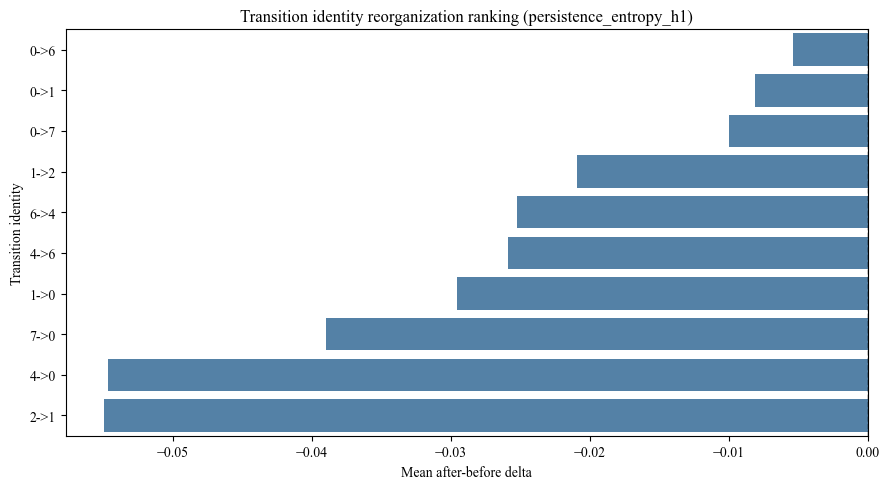

,transition_identity,mean_delta,median_delta,n_switches,feature
0,0->1,0.011952,0.008765,3932,total_persistence_h1
1,0->2,0.102489,0.045560,280,total_persistence_h1
2,0->3,0.043114,0.079651,130,total_persistence_h1
3,0->4,0.773343,0.773343,1,total_persistence_h1
4,0->5,0.183129,0.141586,33,total_persistence_h1
5,0->6,0.000396,0.004920,4500,total_persistence_h1
6,0->7,0.037864,0.041278,1770,total_persistence_h1
7,1->0,-0.100919,-0.114198,4004,total_persistence_h1
8,1->2,-0.013693,-0.018360,1858,total_persistence_h1
9,1->3,-0.036102,-0.034258,828,total_persistence_h1


ValueError: underlying array is read-only

In [7]:
df_session_robustness, df_session_robustness_summary = run_session_level_robustness(
    df_main,
    df_growth,
    FIG_DIR,
    TAB_DIR,
)
df_posterior_control_input, df_posterior_control_models = run_posterior_control_analysis(
    df_main,
    df_growth,
    FIG_DIR,
    TAB_DIR,
)
transition_identity_results = run_transition_identity_analysis(
    df_main,
    df_growth,
    TOPO_FEATURES,
    FIG_DIR,
    TAB_DIR,
)
df_transition_rankings = transition_identity_results['rankings']
df_transition_pair_summary = transition_identity_results['pair_summary']


## 8. Session-Level Moderation by Regime Geometry

This section aggregates real-switch post-switch slopes to the session level and tests whether session-level arc magnitude varies with regime-geometry PC1 (volatility) and PC2 (irregularity), with therapist random intercepts and an additional quadratic-PC1 specification.



/Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may 

,session_id,mean_post_switch_slope,median_post_switch_slope,n_real_switches,mean_after_before_delta,median_after_before_delta,dyad_id,PC1,PC2,PC3,therapist_group,switching_rate,mean_dwell,cv_dwell,trans_entropy,occ_entropy,z_PC1,z_PC2,z_PC1_sq
0,001_A,-0.012448,-0.015505,128,-0.089493,-0.140125,1,-1.824515,0.323922,-1.289612,THER_A,0.373842,2.673267,1.335436,1.043339,1.966958,-1.009145,0.236010,1.018374
1,001_B,-0.026812,-0.025571,130,-0.018669,0.021927,1,-2.061922,-0.189704,-0.630533,THER_A,0.335309,2.980132,1.160025,1.107274,2.204951,-1.144628,-0.266153,1.310174
2,002_A,-0.018882,-0.011350,117,-0.107710,-0.075909,2,-1.665628,0.584461,-0.299341,THER_B,0.329752,3.030303,1.699739,1.036965,2.223303,-0.918471,0.490735,0.843590
3,002_B,-0.027084,-0.030840,85,-0.140570,-0.097285,2,1.079166,1.140028,-1.042251,THER_B,0.248240,4.023845,2.147580,0.632510,1.576061,0.647922,1.033903,0.419804
4,004_A,-0.008441,-0.003889,92,-0.026260,0.069386,4,-0.869332,-0.729216,-0.950019,THER_B,0.260534,3.831818,0.959968,1.013353,1.895649,-0.464043,-0.793624,0.215336
5,004_B,0.000126,0.000000,122,0.165873,0.109715,4,-2.704664,0.216981,0.663604,THER_B,0.354946,2.815433,1.479984,1.055466,2.795759,-1.511427,0.131456,2.284411
6,007_A,-0.034384,-0.029715,70,-0.071054,-0.114597,7,0.984122,0.095746,-0.993625,THER_D,0.210819,4.736842,1.603356,0.728534,1.589010,0.593683,0.012927,0.352459
7,007_B,-0.022604,-0.018773,79,0.005939,0.025274,7,0.376516,-0.582327,-0.105219,THER_D,0.193683,5.153110,1.306482,0.791610,2.004582,0.246936,-0.650013,0.060977
8,009_A,-0.024100,-0.009850,51,-0.000534,0.158778,9,2.793497,0.276357,-0.183112,THER_E,0.127455,7.826087,2.146829,0.595940,1.471097,1.626254,0.189507,2.644701
9,009_B,-0.018013,-0.005147,130,-0.142710,-0.127718,9,0.198714,-0.348722,-0.739406,THER_E,0.220064,4.538462,1.324946,0.854590,1.792094,0.145468,-0.421621,0.021161


,outcome,model_name,n_sessions,n_therapists,aic,bic,coef_const,p_const,coef_z_PC1,p_z_PC1,coef_z_PC2,p_z_PC2,coef_Group Var,p_Group Var,coef_z_PC1_sq,p_z_PC1_sq
0,mean_post_switch_slope,linear,108,20,-691.809212,-678.398556,-2.061565e-02,8.671375e-112,-0.005833,2.486132e-09,0.002498,0.016588,1.477355e-08,1.000000,NaN,NaN
1,mean_post_switch_slope,quadratic_pc1,108,20,-689.975549,-673.882762,-2.083395e-02,2.606740e-86,-0.005988,1.076090e-08,0.002440,0.021052,8.225621e-08,0.999999,0.000218,0.683396
2,mean_after_before_delta,linear,108,20,-187.658265,-174.247609,1.240407e-19,1.000000e+00,-0.000439,9.639207e-01,-0.010468,0.290728,3.863644e-33,1.000000,NaN,NaN
3,mean_after_before_delta,quadratic_pc1,108,20,-203.179849,-187.087062,-3.737102e-02,8.857539e-04,-0.002652,7.880420e-01,-0.005449,0.554486,3.779484e-02,0.496120,0.004342,0.400140


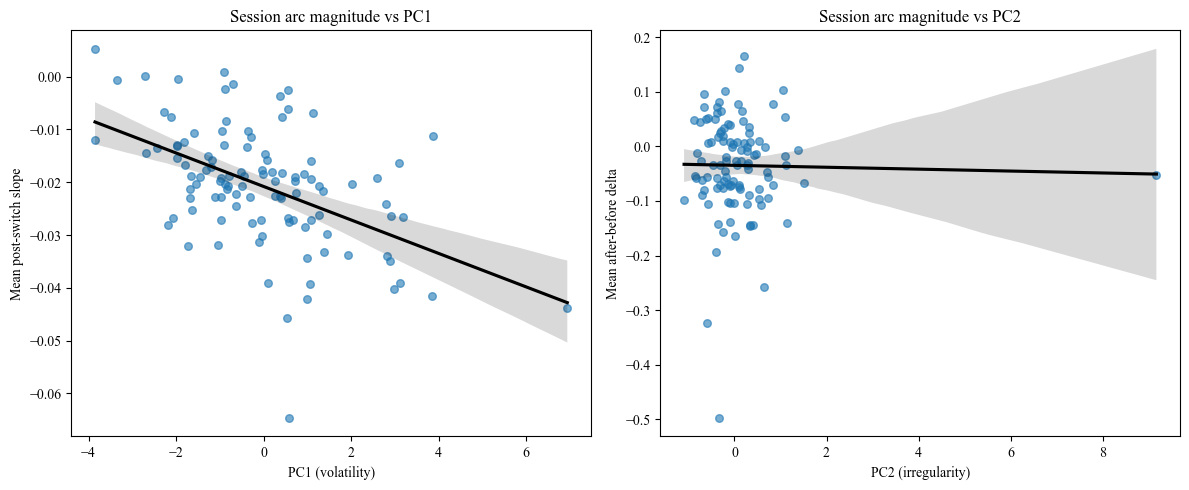

In [8]:
session_geometry_results = run_session_geometry_analysis(
    df_main,
    df_growth,
    CHMM_DIR,
    Path('../data/demographics_alliance/cleaned_outputs/therapist_summary_long.csv'),
    FIG_DIR,
    TAB_DIR,
)
df_session_arc = session_geometry_results['df_session_arc']
df_session_geometry = session_geometry_results['df_session_geometry']
df_session_arc_analysis = session_geometry_results['df_session_arc_analysis']
df_session_arc_models = session_geometry_results['df_session_arc_models']



## 9. Publication Figures
This section builds an expanded manuscript-style figure set: the core real-versus-pseudo effect, a cleaner continuous-moderator figure for posterior jump and regime dwell, a compact summary of continuous and fluctuation effects, an affect-direction companion figure, and the session-level moderation figure. All figures are saved as SVGs in the notebook figures directory.

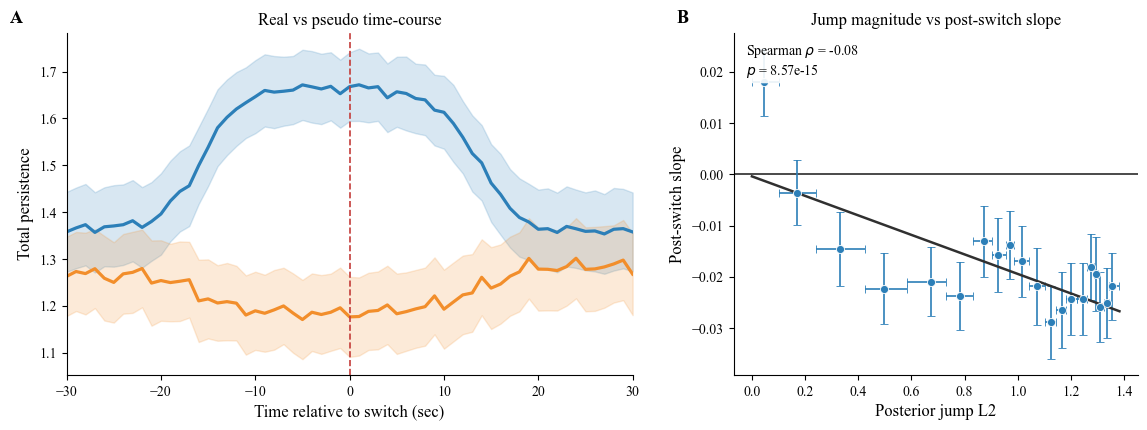

/Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


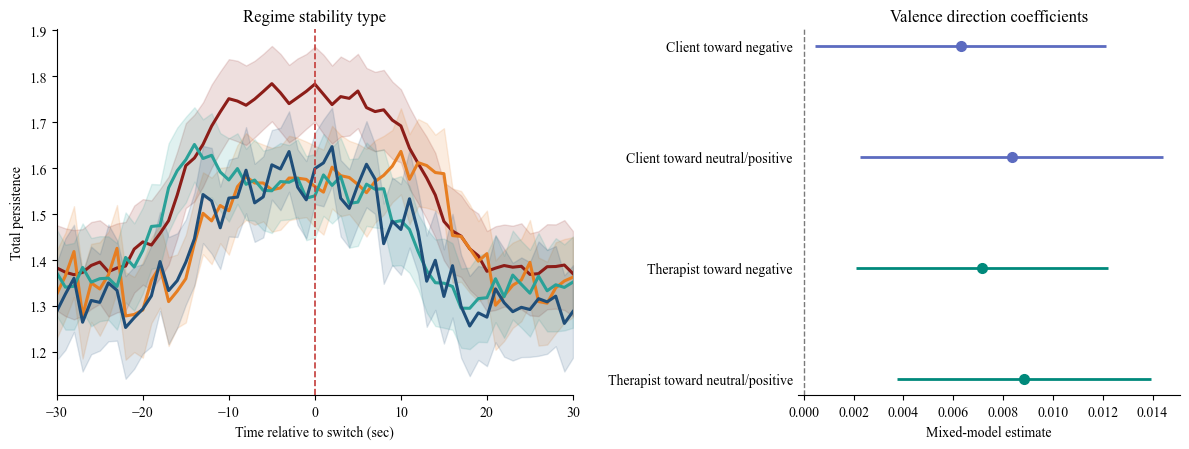

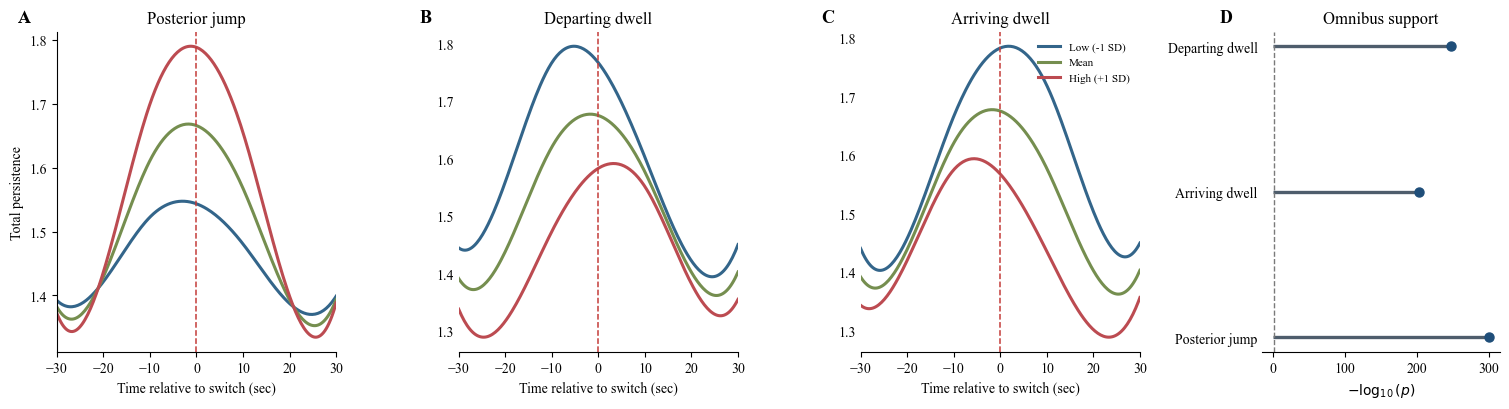

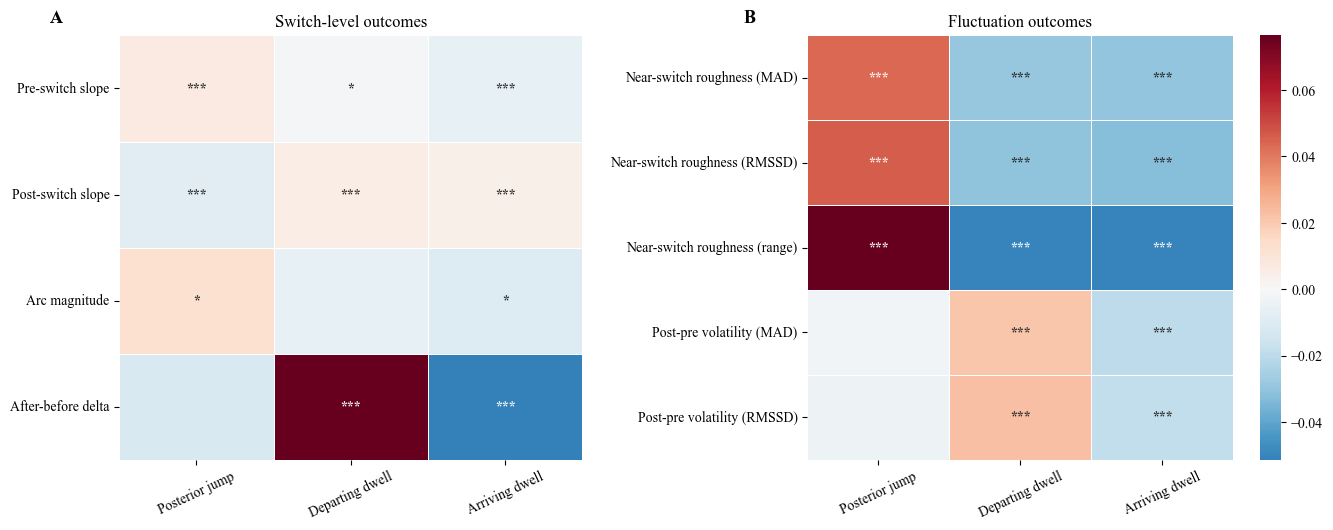

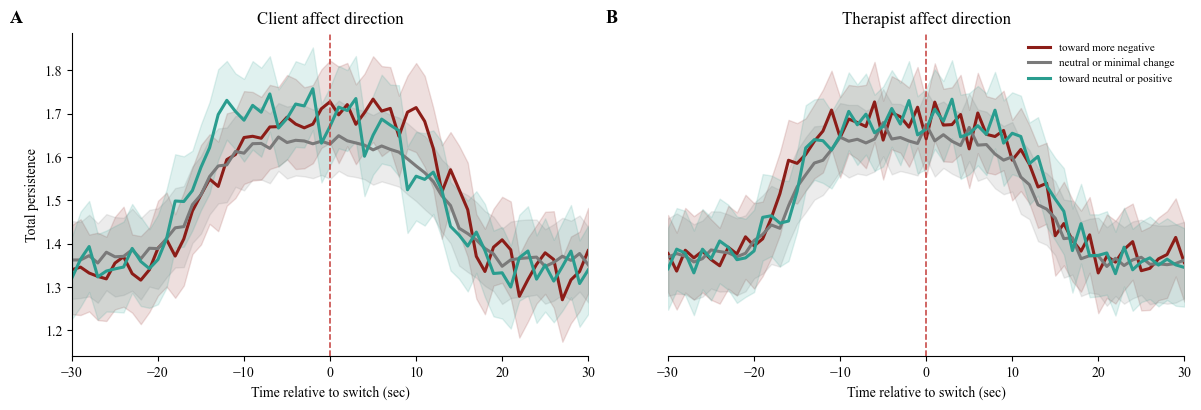

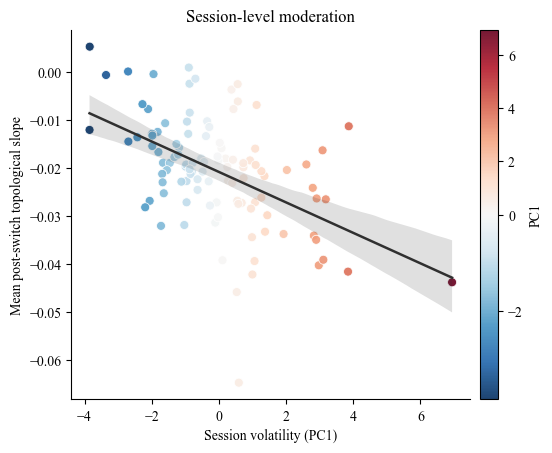

In [9]:
publication_figures = make_publication_figures(
    df_main,
    df_growth,
    df_growth_moderation_input,
    df_session_arc_analysis,
    FIG_DIR,
    TAB_DIR,
    df_continuous_moderator_models=df_continuous_moderator_models,
    df_continuous_moderator_predicted_curves=df_continuous_moderator_predicted_curves,
    df_growth_continuous_transition_models=df_growth_continuous_transition_models,
    df_fluctuation_models=df_fluctuation_models,
    df_client_valence_moderator_summary=df_client_valence_moderator_summary,
    df_therapist_valence_moderator_summary=df_therapist_valence_moderator_summary,
)
df_figure1_timecourse_summary = publication_figures['figure1_timecourse_summary']
df_figure1_slope_summary = publication_figures['figure1_slope_summary']
df_figure2_stability_summary = publication_figures['figure2_stability_summary']
df_figure2_valence_coefficients = publication_figures['figure2_valence_coefficients']
df_figure2_continuous_curves = publication_figures['figure2_continuous_curves']
df_figure3_effect_summary = publication_figures['figure3_effect_summary']
df_figure3_session_scatter = publication_figures['figure3_session_scatter']
df_figureS1_affect_client_summary = publication_figures['figureS1_affect_client_summary']
df_figureS1_affect_therapist_summary = publication_figures['figureS1_affect_therapist_summary']

## 10. Compact Results Index


In [ ]:
results_index = {
    "tables": {
        "primary_timecourse_summary": str(TAB_DIR / "primary_real_vs_pseudo_timecourses_summary.csv"),
        "primary_time_x_anchor_model_summary": str(TAB_DIR / "primary_time_x_anchor_model_summary.csv"),
        "difference_curves": str(TAB_DIR / "primary_real_minus_pseudo_difference_curves.csv"),
        "switch_growth_slopes": str(TAB_DIR / "switch_growth_slopes.csv"),
        "switch_growth_slope_summary": str(TAB_DIR / "switch_growth_slope_summary.csv"),
        "switch_growth_anchor_kind_mixed_model": str(TAB_DIR / "switch_growth_anchor_kind_mixed_model.csv"),
        "switch_growth_jump_association": str(TAB_DIR / "switch_growth_jump_association.csv"),
        "switch_growth_moderation_input": str(TAB_DIR / "switch_growth_moderation_input.csv"),
        "switch_growth_moderation_mixed_models": str(TAB_DIR / "switch_growth_moderation_mixed_models.csv"),
        "switch_growth_continuous_dwell_mixed_models": str(TAB_DIR / "switch_growth_continuous_dwell_mixed_models.csv"),
        "switch_growth_continuous_transition_mixed_models": str(TAB_DIR / "switch_growth_continuous_transition_mixed_models.csv"),
        "moderator_timecourse_omnibus_model_summary": str(TAB_DIR / "moderator_timecourse_omnibus_model_summary.csv"),
        "continuous_moderator_timecourse_omnibus_model_summary": str(TAB_DIR / "continuous_moderator_timecourse_omnibus_model_summary.csv"),
        "continuous_moderator_timecourse_predicted_curves": str(TAB_DIR / "continuous_moderator_timecourse_predicted_curves.csv"),
        "continuous_moderator_correlation_matrix_long": str(TAB_DIR / "continuous_moderator_correlation_matrix_long.csv"),
        "switch_fluctuation_analysis_table": str(TAB_DIR / "switch_fluctuation_analysis_table.csv"),
        "switch_fluctuation_mixed_models": str(TAB_DIR / "switch_fluctuation_mixed_models.csv"),
        "moderator_jump_magnitude_model_summary": str(TAB_DIR / "moderator_jump_magnitude_timecourses_real_only_model_summary.csv"),
        "moderator_regime_stability_model_summary": str(TAB_DIR / "moderator_regime_stability_timecourses_real_only_model_summary.csv"),
        "moderator_client_valence_model_summary": str(TAB_DIR / "moderator_client_valence_direction_timecourses_real_only_model_summary.csv"),
        "moderator_therapist_valence_model_summary": str(TAB_DIR / "moderator_therapist_valence_direction_timecourses_real_only_model_summary.csv"),
        "moderator_jump_magnitude_predicted_curves": str(TAB_DIR / "moderator_jump_magnitude_timecourses_real_only_predicted_curves.csv"),
        "moderator_regime_stability_predicted_curves": str(TAB_DIR / "moderator_regime_stability_timecourses_real_only_predicted_curves.csv"),
        "moderator_client_valence_predicted_curves": str(TAB_DIR / "moderator_client_valence_direction_timecourses_real_only_predicted_curves.csv"),
        "moderator_therapist_valence_predicted_curves": str(TAB_DIR / "moderator_therapist_valence_direction_timecourses_real_only_predicted_curves.csv"),
        "session_level_robustness_values": str(TAB_DIR / "session_level_robustness_values.csv"),
        "session_level_robustness_wilcoxon": str(TAB_DIR / "session_level_robustness_wilcoxon.csv"),
        "posterior_control_analysis_input": str(TAB_DIR / "posterior_control_analysis_input.csv"),
        "posterior_control_models": str(TAB_DIR / "posterior_control_models.csv"),
        "transition_pair_heterogeneity_summary": str(TAB_DIR / "transition_pair_heterogeneity_summary.csv"),
        "transition_pair_counts_matrix": str(TAB_DIR / "transition_pair_counts_matrix.csv"),
        "transition_pair_arc_magnitude_matrix": str(TAB_DIR / "transition_pair_arc_magnitude_matrix.csv"),
        "transition_pair_post_switch_slope_matrix": str(TAB_DIR / "transition_pair_post_switch_slope_matrix.csv"),
        "session_arc_geometry_analysis_table": str(TAB_DIR / "session_arc_geometry_analysis_table.csv"),
        "session_arc_geometry_mixed_models": str(TAB_DIR / "session_arc_geometry_mixed_models.csv"),
        "figure1_total_persistence_timecourse_summary": str(TAB_DIR / "figure1_total_persistence_timecourse_summary.csv"),
        "figure1_total_persistence_slope_summary": str(TAB_DIR / "figure1_total_persistence_slope_summary.csv"),
        "figure2_regime_stability_timecourse_summary": str(TAB_DIR / "figure2_regime_stability_timecourse_summary.csv"),
        "figure2_valence_direction_coefficients": str(TAB_DIR / "figure2_valence_direction_coefficients.csv"),
        "figure2_continuous_moderator_curves_total_persistence": str(TAB_DIR / "figure2_continuous_moderator_curves_total_persistence.csv"),
        "figure3_continuous_effect_summary_total_persistence": str(TAB_DIR / "figure3_continuous_effect_summary_total_persistence.csv"),
        "figureS1_client_affect_direction_total_persistence": str(TAB_DIR / "figureS1_client_affect_direction_total_persistence.csv"),
        "figureS1_therapist_affect_direction_total_persistence": str(TAB_DIR / "figureS1_therapist_affect_direction_total_persistence.csv"),
        "figure3_session_level_pc1_scatter": str(TAB_DIR / "figure3_session_level_pc1_scatter.csv"),
    },
    "figures": {
        "primary_real_vs_pseudo_timecourses": str(FIG_DIR / "primary_real_vs_pseudo_timecourses.svg"),
        "primary_timecourse_models_and_difference_curves": str(FIG_DIR / "primary_timecourse_models_and_difference_curves.svg"),
        "switch_growth_slopes_by_anchor": str(FIG_DIR / "switch_growth_slopes_by_anchor.svg"),
        "switch_growth_vs_jump_scatter": str(FIG_DIR / "switch_growth_vs_jump_scatter.svg"),
        "moderator_jump_magnitude_model_curves": str(FIG_DIR / "moderator_jump_magnitude_timecourses_real_only_model_curves.svg"),
        "moderator_regime_stability_model_curves": str(FIG_DIR / "moderator_regime_stability_timecourses_real_only_model_curves.svg"),
        "moderator_client_valence_model_curves": str(FIG_DIR / "moderator_client_valence_direction_timecourses_real_only_model_curves.svg"),
        "moderator_therapist_valence_model_curves": str(FIG_DIR / "moderator_therapist_valence_direction_timecourses_real_only_model_curves.svg"),
        "continuous_moderator_timecourse_model_curves": str(FIG_DIR / "continuous_moderator_timecourses_real_only_model_curves.svg"),
        "session_level_robustness_summary": str(FIG_DIR / "session_level_robustness_summary.svg"),
        "transition_pair_heterogeneity_heatmaps": str(FIG_DIR / "transition_pair_heterogeneity_heatmaps.svg"),
        "figure1_total_persistence_primary": str(FIG_DIR / "figure1_total_persistence_primary.svg"),
        "figure2_moderators_total_persistence": str(FIG_DIR / "figure2_moderators_total_persistence.svg"),
        "figure2_continuous_moderators_total_persistence": str(FIG_DIR / "figure2_continuous_moderators_total_persistence.svg"),
        "figure3_transition_fluctuation_summary": str(FIG_DIR / "figure3_transition_fluctuation_summary.svg"),
        "figure3_session_level_moderation": str(FIG_DIR / "figure3_session_level_moderation.svg"),
        "figureS1_affect_direction_total_persistence": str(FIG_DIR / "figureS1_affect_direction_total_persistence.svg"),
    },
}
results_index